Notebook to place a pattern on a FIB image

In [17]:
# general
from copy import deepcopy

# for display
import napari
import matplotlib.pyplot as plt
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm
gm.init_model_with_path(model_path=r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp")

2024-12-19 14:27:54,750 — root — INFO — __init__:174 — model path:C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp
2024-12-19 14:27:54,751 — root — INFO — __init__:180 — DL device: cuda


In [18]:
# Set up test microscope
config_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml"
protocol_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\scripts\spoof_microscope_protocol.yaml"
PIXEL_SIZE_M = 1.3020833333333335e-08

microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2024-12-19 14:27:55,653 — root — INFO — connect_to_microscope:5403 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2024-12-19 14:27:55,655 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2024-12-19-02-27-55PM


In [19]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2024-12-19 14:27:55,664 — root — INFO — acquire_image:6383 — acquiring new ELECTRON image.
2024-12-19 14:27:55,665 — root — INFO — acquire_image:6384 — resolution:[1536, 1024], hfw:4e-05
2024-12-19 14:27:55,667 — root — INFO — acquire_image:6391 — SEM
2024-12-19 14:27:55,667 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\01A_SEM_mill.tif as spoof image
2024-12-19 14:28:00,640 — root — INFO — acquire_image:6418 — img_data.type:<class 'numpy.ndarray'>
2024-12-19 14:28:00,641 — root — INFO — acquire_image:6419 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2024-12-19 14:28:00,642 — root — INFO — acquire_image:6423 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2024-12-19 14:28:00,839 — root — INFO — acquire_image:6427 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2024-12-19 14:28:00,840 — root — INFO — acquire_image:6441 — data_uint

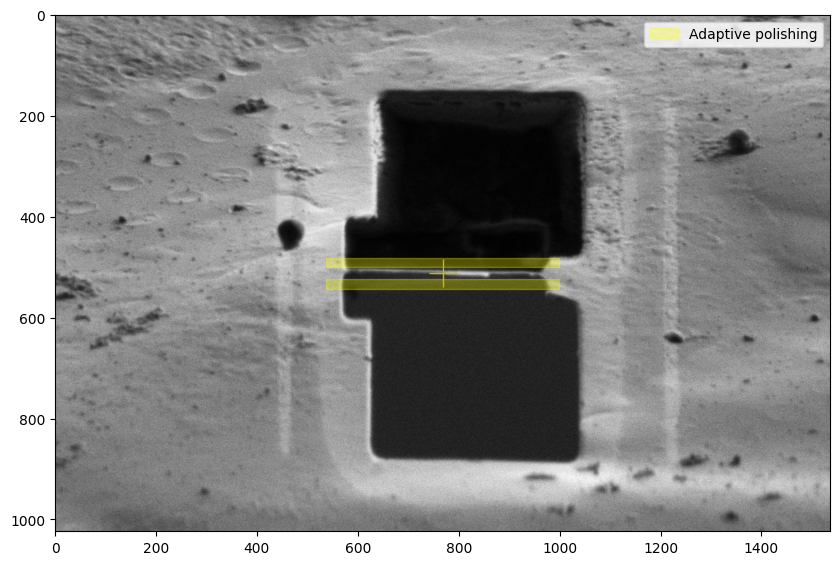

In [20]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

2024-12-19 14:28:05,845 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2024-12-19 14:28:05,871 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2024-12-19 14:28:05,886 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2024-12-19 14:28:06,211 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:1.3020833333333335e-08
2024-12-19 14:28:06,242 — root — INFO — measure_GIS:118 — window_size_px: 7
2024-12-19 14:28:06,245 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 4.7005208333333335e-06 m


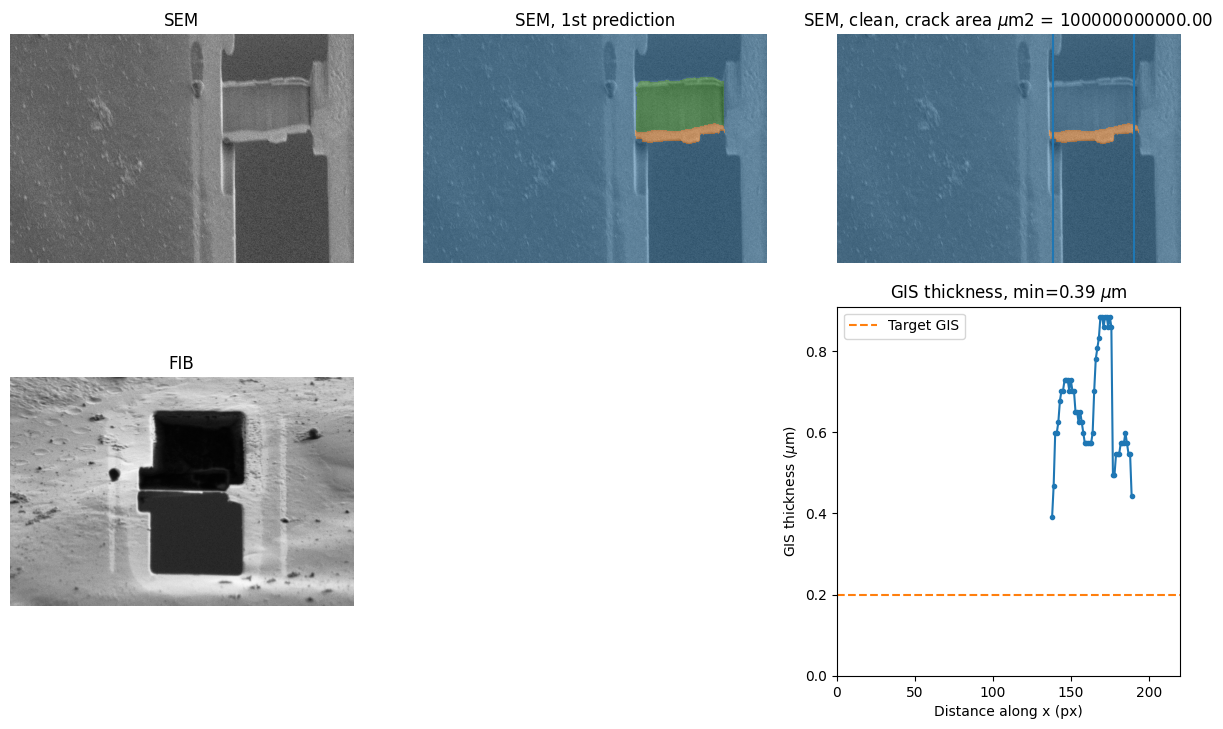

In [21]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = gm.measure_GIS(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=2e-7,
    crack_area_m2=0.1,
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
    )
lamella_width = (xlims[1] - xlims[0]) * PIXEL_SIZE_M
print(f"Lamella width is {lamella_width} m")

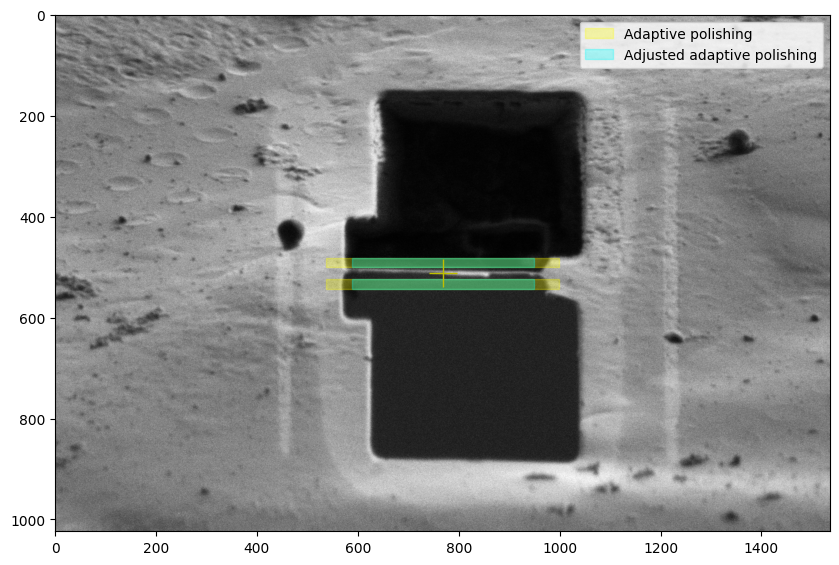

In [ ]:
# Place pattern on image from edited pattern
ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
ap_milling_protocol["lamella_width"] = lamella_width * 2  # why x2??
ap_milling_protocol["hfw"] = 4e-05
ap_milling_protocol["trench_height"] = 5e-7
ap_milling_protocol["name"] = "Adjusted adaptive polishing"
if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)